In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
input = pd.read_csv(r'Dataset\extracted_dataset\non-multisegment\non-multisegment_input.csv')
src = pd.read_csv(r'Dataset\extracted_dataset\non-multisegment\non-multisegment_output.csv')

In [3]:
input.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# maxi1=0.0
# mini1=1e6
# s1=''

# df=df_output
# for i in df['filename'].unique():
#     print(i)
#     r=maxi1
#     maxi1=max(maxi1,(df[df['filename']==i]['LON'].max()-df[df['filename']==i]['LON'].min())*inv[inv['filename']==i]['Dx'].values[0])
#     maxi1=max(maxi1,(df[df['filename']==i]['LAT'].max()-df[df['filename']==i]['LAT'].min())*inv[inv['filename']==i]['Dx'].values[0])
#     if(r<maxi1):
#         s1=i
#     mini1=min(mini1,(df[df['filename']==i]['LON'].max()-df[df['filename']==i]['LON'].min())*inv[inv['filename']==i]['Dx'].values[0])
#     mini1=min(mini1,(df[df['filename']==i]['LAT'].max()-df[df['filename']==i]['LAT'].min())*inv[inv['filename']==i]['Dx'].values[0])

NameError: name 'df_output' is not defined

-0.9599310820367238


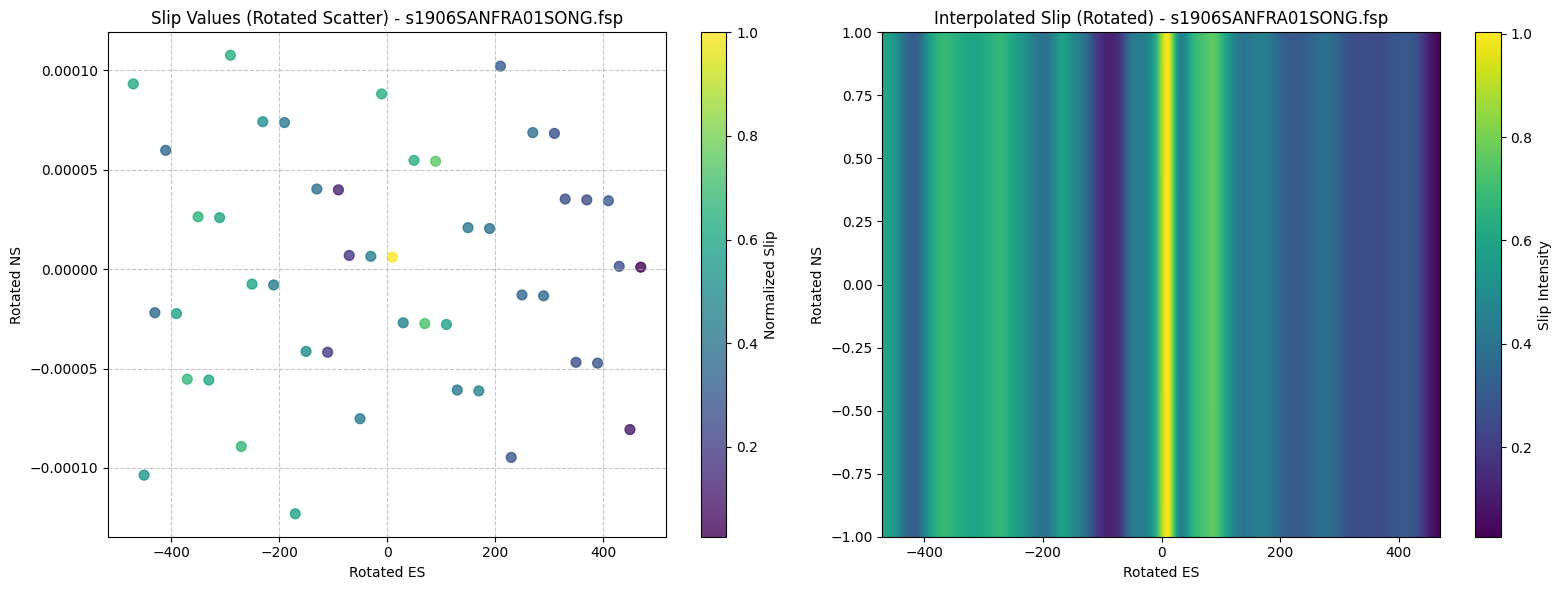

-0.9599310820367238


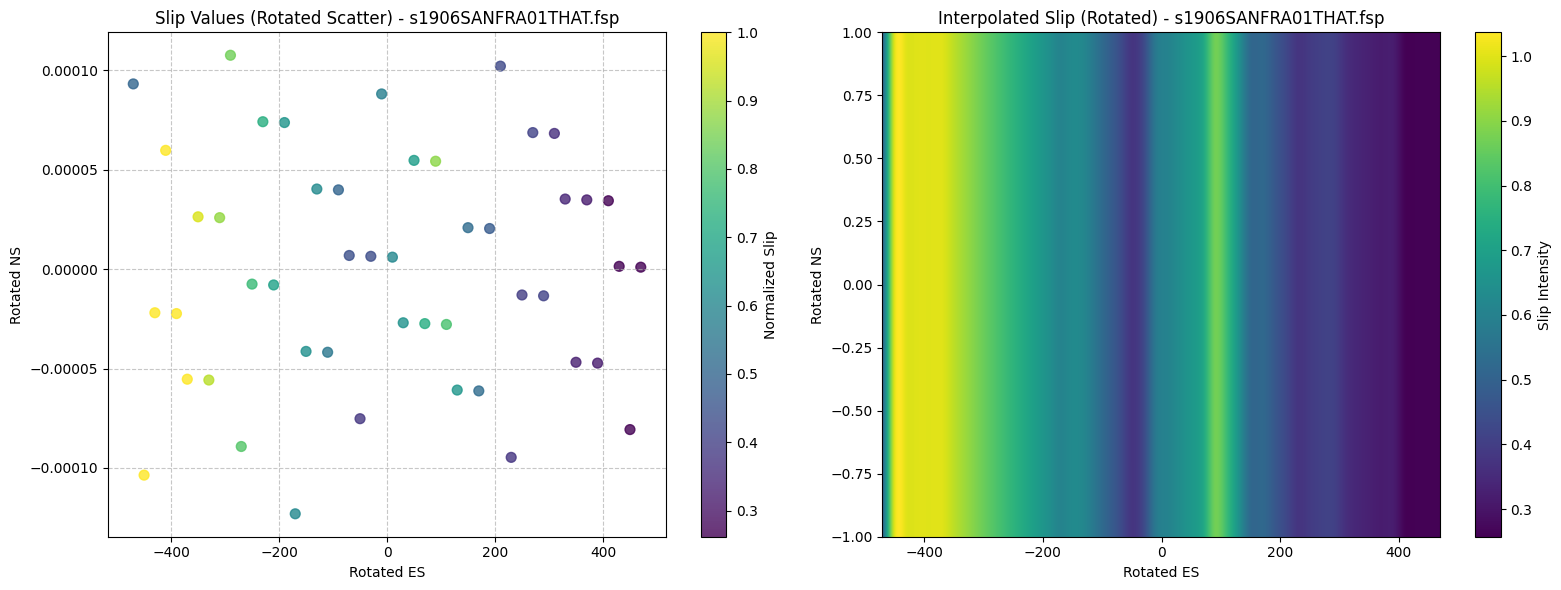

-0.2635050225767742


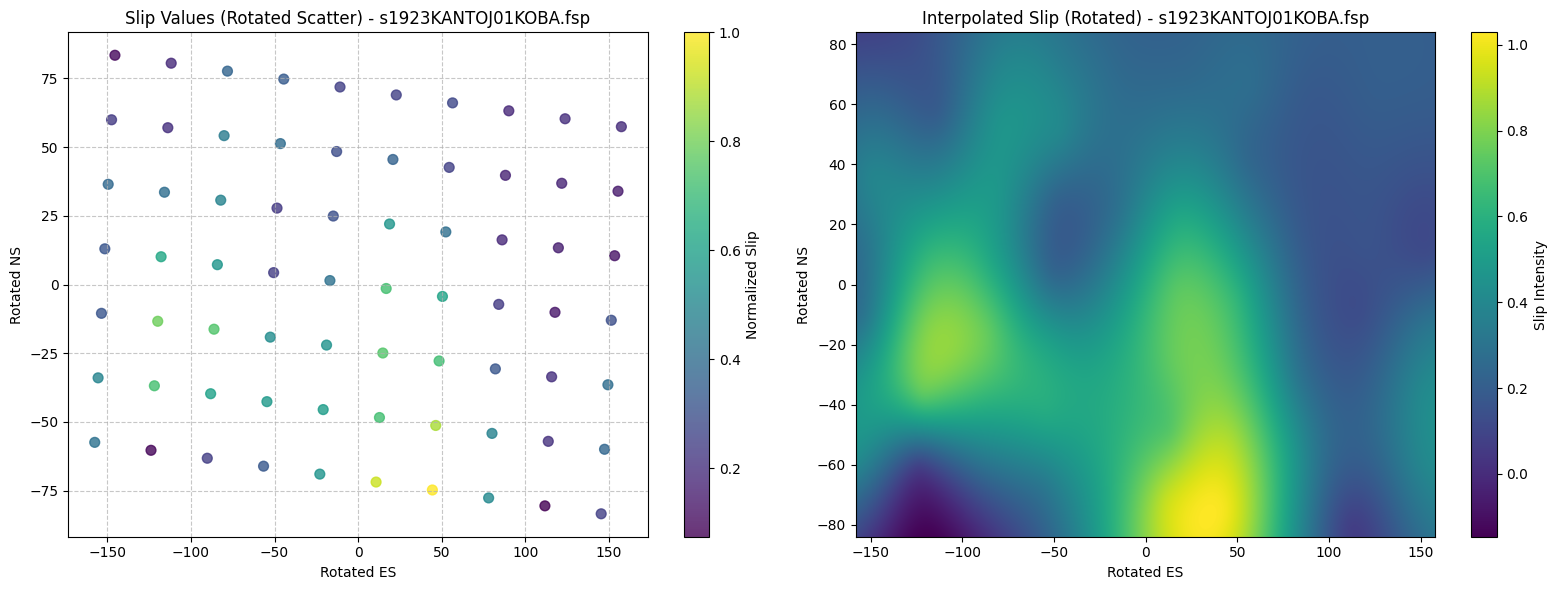

0.3684109052302891
Spline interpolation failed for file: s1944TONANK01ICHI.fsp. Error: Unable to allocate 32.0 GiB for an array with shape (55818000, 77) and data type float64
0.23273255628106942


KeyboardInterrupt: 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf  # Radial Basis Function for spline interpolation

def rotate_points(x, y, angle):
    x_rot = x * np.cos(angle) - y * np.sin(angle)
    y_rot = x * np.sin(angle) + y * np.cos(angle)
    return x_rot, y_rot

c = 0
for i in src['filename'].unique():
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # print(es)
    c+=1
    # print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # --- Step 2.5: Find slope & rotate so diagonal is horizontal ---
    m, b = np.polyfit(es_centered, ns_centered, 1)
    theta = np.arctan(m)
    # print(theta)
    es_rotated, ns_rotated = rotate_points(es_centered, ns_centered, -theta)

    # --- Step 3: Define the grid in rotated space ---
    x_min = int(np.floor(np.min(es_rotated)))
    x_max = int(np.ceil(np.max(es_rotated)))
    y_min = int(np.floor(np.min(ns_rotated)))
    y_max = int(np.ceil(np.max(ns_rotated)))

    # Create a finer grid for smoother interpolation
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, (x_max-x_min)*10),  # Higher resolution
        np.linspace(y_min, y_max, (y_max-y_min)*10)   
    )

    # --- Step 4: Interpolate with thin-plate splines ---
    try:
        # Filter out any NaN values
        valid_indices = ~np.isnan(slip)
        x_valid = es_rotated[valid_indices]
        y_valid = ns_rotated[valid_indices]
        slip_valid = slip[valid_indices]
        
        # Create RBF interpolator with thin-plate splines
        rbf = Rbf(x_valid, y_valid, slip_valid, function='thin_plate')
        
        # Evaluate on grid
        grid_slip = rbf(grid_x, grid_y)
        
    except Exception as e:
        print(f"Spline interpolation failed for file: {i}. Error: {e}")
        continue

    # --- Steps 5 & 6: Plotting and saving (unchanged) ---
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Scatter plot of the original data points
    scatter = ax1.scatter(es_rotated, ns_rotated, c=slip, 
                          cmap='viridis', s=50, alpha=0.8)
    fig.colorbar(scatter, ax=ax1, label='Normalized Slip')
    ax1.set_title(f"Slip Values (Rotated Scatter) - {i}")
    ax1.set_xlabel("Rotated ES")
    ax1.set_ylabel("Rotated NS")
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: Interpolated grid image
    im = ax2.imshow(grid_slip, 
                   extent=(x_min, x_max, y_min, y_max),
                   origin='lower', 
                   cmap='viridis', 
                   aspect='auto')
    fig.colorbar(im, ax=ax2, label='Slip Intensity')
    ax2.set_title(f"Interpolated Slip (Rotated) - {i}")
    ax2.set_xlabel("Rotated ES")
    ax2.set_ylabel("Rotated NS")
    
    # Add some spacing between subplots and adjust layout
    plt.tight_layout()
    plt.show()

    if c > 5:
        break
        # plt.savefig(f"interpolated_slip_image_{i}.png", dpi=300)    

    # plt.imsave(f"interpolated_slip_image_{i}.png", grid_slip, cmap='viridis',
    #            vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))

1


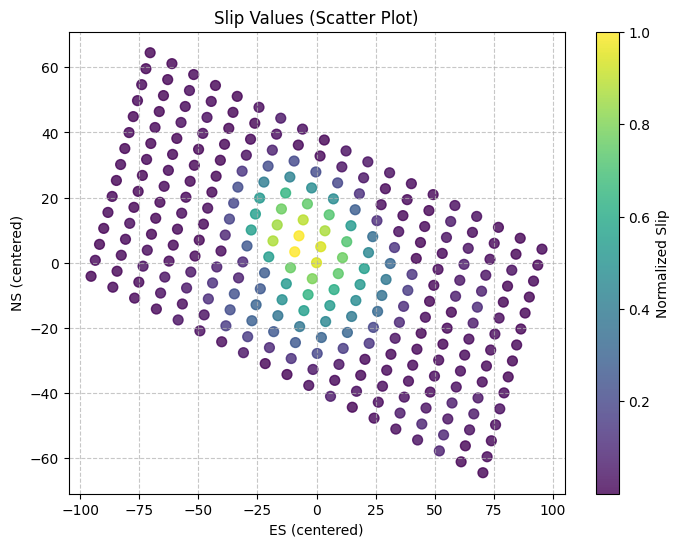

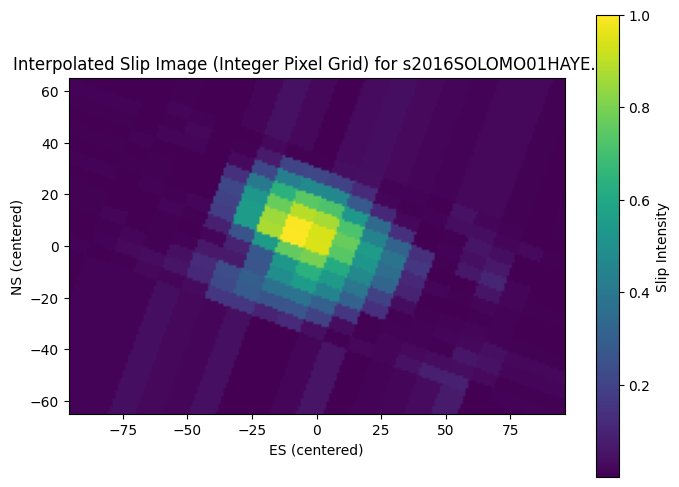

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
c=0
for i in src['filename'].unique():

    if i[:-4] != 's2016SOLOMO01HAYE':
        continue
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # print(es)
    c+=1
    print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='nearest', fill_value=0)

    except:
        print(i)
        continue

    # Optionally, you can replace NaNs (outside the convex hull of your data)
    # # For example, with zeros or using nearest neighbor interpolation:
    # grid_slip = np.where(np.isnan(grid_slip),
    #                      griddata(points, slip, (grid_x, grid_y), method='nearest'),
    #                      grid_slip)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(es_centered, ns_centered, c=slip, 
                        cmap='viridis', s=50, alpha=0.8)
    plt.colorbar(scatter, label='Normalized Slip')
    plt.title("Slip Values (Scatter Plot)")
    plt.xlabel("ES (centered)")
    plt.ylabel("NS (centered)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


    # Step 5: Visualize the image.
    plt.figure(figsize=(8, 6))
    plt.imshow(grid_slip, extent=(x_min, x_max, y_min, y_max),
            origin='lower', cmap='viridis')
    plt.colorbar(label='Slip Intensity')
    plt.title(f"Interpolated Slip Image (Integer Pixel Grid) for {i}")
    plt.xlabel("ES (centered)")
    plt.ylabel("NS (centered)")
    plt.show()

    
    # # Optionally, save the image.
    # plt.imsave("interpolated_slip_image.png", grid_slip, cmap='viridis',
    #         vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))
    
    # break

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf  # Radial Basis Function for spline interpolation

def rotate_points(x, y, angle):
    x_rot = x * np.cos(angle) - y * np.sin(angle)
    y_rot = x * np.sin(angle) + y * np.cos(angle)
    return x_rot, y_rot

c = 0
for i in df['filename'].unique():
    # --- Step 1: Extract & Scale Data ---
    es = df[df['filename']==i]['X==EW'].values * inv[inv['filename']==i]['Dx'].values[0]/5
    ns = df[df['filename']==i]['Y==NS'].values * inv[inv['filename']==i]['Dx'].values[0]/5
    slip = df[df['filename']==i]['SLIP'].values / df['SLIP'].max()
    
    c += 1
    print(f"Processing file {i} (count={c})")

    # --- Step 2: Re-center ---
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # --- Step 2.5: Find slope & rotate so diagonal is horizontal ---
    m, b = np.polyfit(es_centered, ns_centered, 1)
    theta = np.arctan(m)
    print(theta)
    es_rotated, ns_rotated = rotate_points(es_centered, ns_centered, -theta)

    # --- Step 3: Define the grid in rotated space ---
    x_min = int(np.floor(np.min(es_rotated)))
    x_max = int(np.ceil(np.max(es_rotated)))
    y_min = int(np.floor(np.min(ns_rotated)))
    y_max = int(np.ceil(np.max(ns_rotated)))

    # Create a finer grid for smoother interpolation
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, (x_max-x_min)*10),  # Higher resolution
        np.linspace(y_min, y_max, (y_max-y_min)*10)   
    )

    # --- Step 4: Interpolate with thin-plate splines ---
    try:
        # Filter out any NaN values
        valid_indices = ~np.isnan(slip)
        x_valid = es_rotated[valid_indices]
        y_valid = ns_rotated[valid_indices]
        slip_valid = slip[valid_indices]
        
        # Create RBF interpolator with thin-plate splines
        rbf = Rbf(x_valid, y_valid, slip_valid, function='thin_plate')
        
        # Evaluate on grid
        grid_slip = rbf(grid_x, grid_y)
        
    except Exception as e:
        print(f"Spline interpolation failed for file: {i}. Error: {e}")
        continue

    # --- Steps 5 & 6: Plotting and saving (unchanged) ---
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(es_rotated, ns_rotated, c=slip, cmap='viridis', s=50, alpha=0.8)
    plt.colorbar(scatter, label='Normalized Slip')
    plt.title(f"Slip Values (Rotated Scatter) - {i}")
    plt.xlabel("Rotated ES")
    plt.ylabel("Rotated NS")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(grid_slip, 
               extent=(x_min, x_max, y_min, y_max),
               origin='lower', 
               cmap='viridis', 
               aspect='auto')
    plt.colorbar(label='Slip Intensity')
    plt.title(f"Interpolated Slip (Rotated) - {i}")
    plt.xlabel("Rotated ES")
    plt.ylabel("Rotated NS")
    plt.show()

    # plt.imsave(f"interpolated_slip_image_{i}.png", grid_slip, cmap='viridis',
    #            vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf  # Radial Basis Function for spline interpolation

def rotate_points(x, y, angle):
    x_rot = x * np.cos(angle) - y * np.sin(angle)
    y_rot = x * np.sin(angle) + y * np.cos(angle)
    return x_rot, y_rot

c = 0
for i in df['filename'].unique():
    # --- Step 1: Extract & Scale Data ---
    es = df[df['filename']==i]['X==EW'].values * inv[inv['filename']==i]['Dx'].values[0]/5
    ns = df[df['filename']==i]['Y==NS'].values * inv[inv['filename']==i]['Dx'].values[0]/5
    slip = df[df['filename']==i]['SLIP'].values / df['SLIP'].max()
    
    c += 1
    print(f"Processing file {i} (count={c})")

    # --- Step 2: Re-center ---
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # --- Step 2.5: Find slope & rotate so diagonal is horizontal ---
    m, b = np.polyfit(es_centered, ns_centered, 1)
    theta = np.arctan(m)
    print(theta)
    es_rotated, ns_rotated = rotate_points(es_centered, ns_centered, -theta)

    # --- Step 3: Define the grid in rotated space ---
    x_min = int(np.floor(np.min(es_rotated)))
    x_max = int(np.ceil(np.max(es_rotated)))
    y_min = int(np.floor(np.min(ns_rotated)))
    y_max = int(np.ceil(np.max(ns_rotated)))

    # Create a finer grid for smoother interpolation
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, (x_max-x_min)*10),  # Higher resolution
        np.linspace(y_min, y_max, (y_max-y_min)*10)   
    )

    # --- Step 4: Interpolate with thin-plate splines ---
    try:
        # Filter out any NaN values
        valid_indices = ~np.isnan(slip)
        x_valid = es_rotated[valid_indices]
        y_valid = ns_rotated[valid_indices]
        slip_valid = slip[valid_indices]
        
        # Create RBF interpolator with thin-plate splines
        rbf = Rbf(x_valid, y_valid, slip_valid, function='thin_plate')
        
        # Evaluate on grid
        grid_slip = rbf(grid_x, grid_y)
        
    except Exception as e:
        print(f"Spline interpolation failed for file: {i}. Error: {e}")
        continue

    # --- Steps 5 & 6: Plotting and saving (unchanged) ---
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(es_rotated, ns_rotated, c=slip, cmap='viridis', s=50, alpha=0.8)
    plt.colorbar(scatter, label='Normalized Slip')
    plt.title(f"Slip Values (Rotated Scatter) - {i}")
    plt.xlabel("Rotated ES")
    plt.ylabel("Rotated NS")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.imshow(grid_slip, 
               extent=(x_min, x_max, y_min, y_max),
               origin='lower', 
               cmap='viridis', 
               aspect='auto')
    plt.colorbar(label='Slip Intensity')
    plt.title(f"Interpolated Slip (Rotated) - {i}")
    plt.xlabel("Rotated ES")
    plt.ylabel("Rotated NS")
    plt.show()

    plt.imsave(f"interpolated_slip_image_{i}.png", grid_slip, cmap='viridis',
               vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))

Total unique shapes: 271
Most common shape: 3x3 (Count: 24)


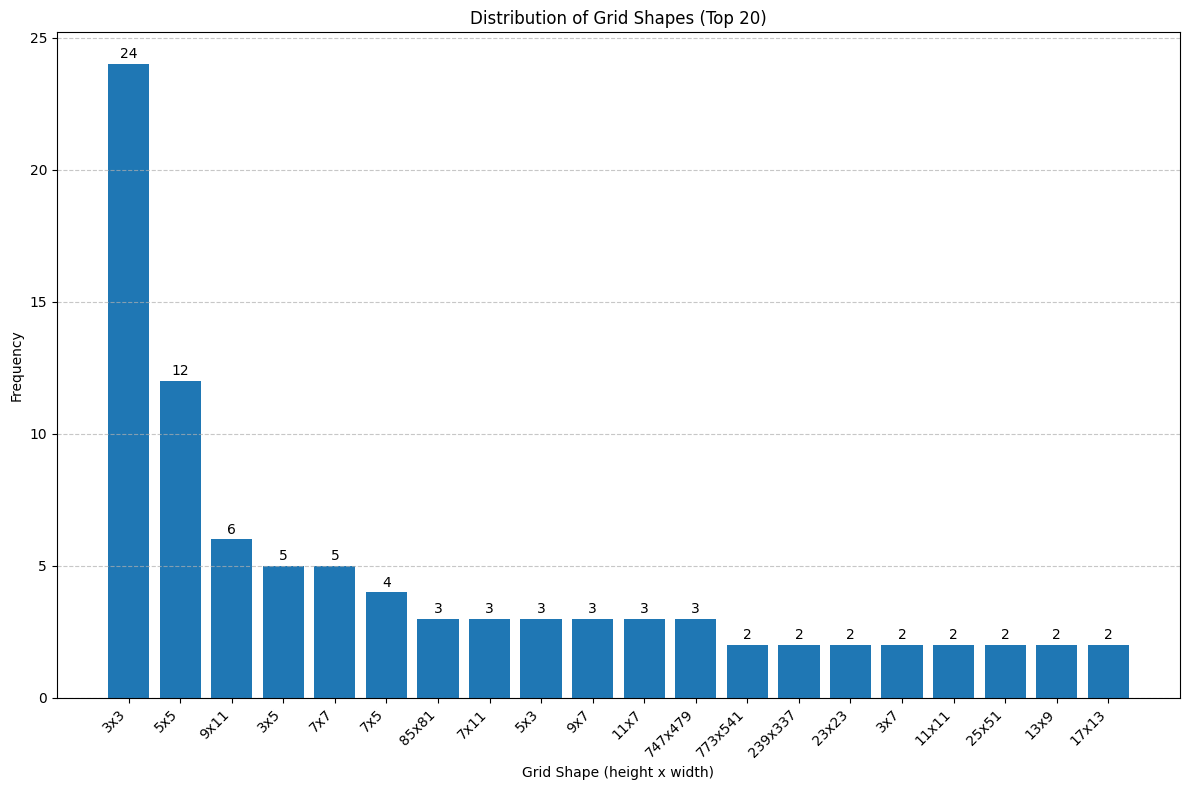

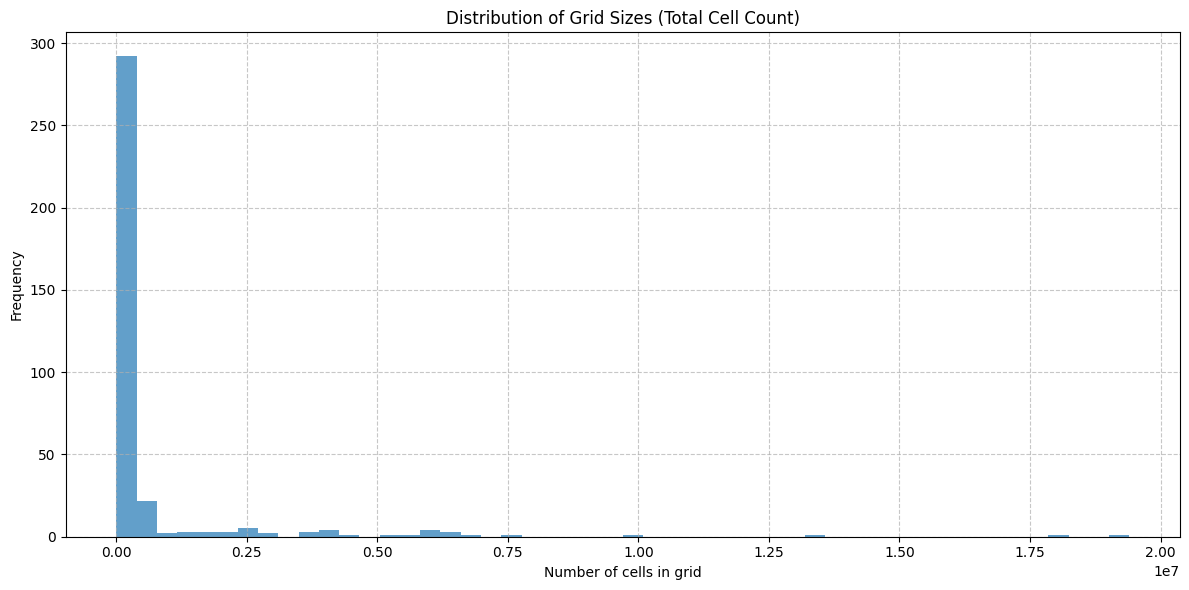

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from collections import Counter

# To store grid shapes 
grid_shapes = []
c=0

for i in src['filename'].unique():
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # c+=1
    # print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='nearest', fill_value=0)
        
        # Store the shape of grid_slip
        grid_shapes.append(grid_slip.shape)
        
    except Exception as e:
        print(f"Error with {i}: {e}")
        continue

# Convert shapes to strings for better visualization
grid_shape_strs = [f"{shape[0]}x{shape[1]}" for shape in grid_shapes]

# Count occurrences of each shape
shape_counts = Counter(grid_shape_strs)

# Sort by frequency
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)

# Plot the distribution of grid shapes
plt.figure(figsize=(12, 8))
bars = plt.bar([item[0] for item in sorted_shapes[:20]], [item[1] for item in sorted_shapes[:20]])

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}', ha='center', va='bottom', rotation=0)

plt.title('Distribution of Grid Shapes (Top 20)')
plt.xlabel('Grid Shape (height x width)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Summary statistics
print(f"Total unique shapes: {len(shape_counts)}")
print(f"Most common shape: {sorted_shapes[0][0]} (Count: {sorted_shapes[0][1]})")

# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

# print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")

# Plot the distribution of grid sizes (total number of cells)
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]

plt.figure(figsize=(12, 6))
plt.hist(grid_sizes, bins=50, alpha=0.7)
plt.title('Distribution of Grid Sizes (Total Cell Count)')
plt.xlabel('Number of cells in grid')
plt.ylabel('Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [9]:
# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")


Largest grid dimensions: 5729x5297
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


In [46]:
slip.min()


np.float64(0.026625258799171842)

c:\Users\atmad\Documents\Python docs\SDA\.venv\lib\site-packages\scipy\interpolate\_ndgriddata.py:327: GradientEstimationWarning: Gradient estimation did not converge, the results may be inaccurate
  ip = CloughTocher2DInterpolator(points, values, fill_value=fill_value,


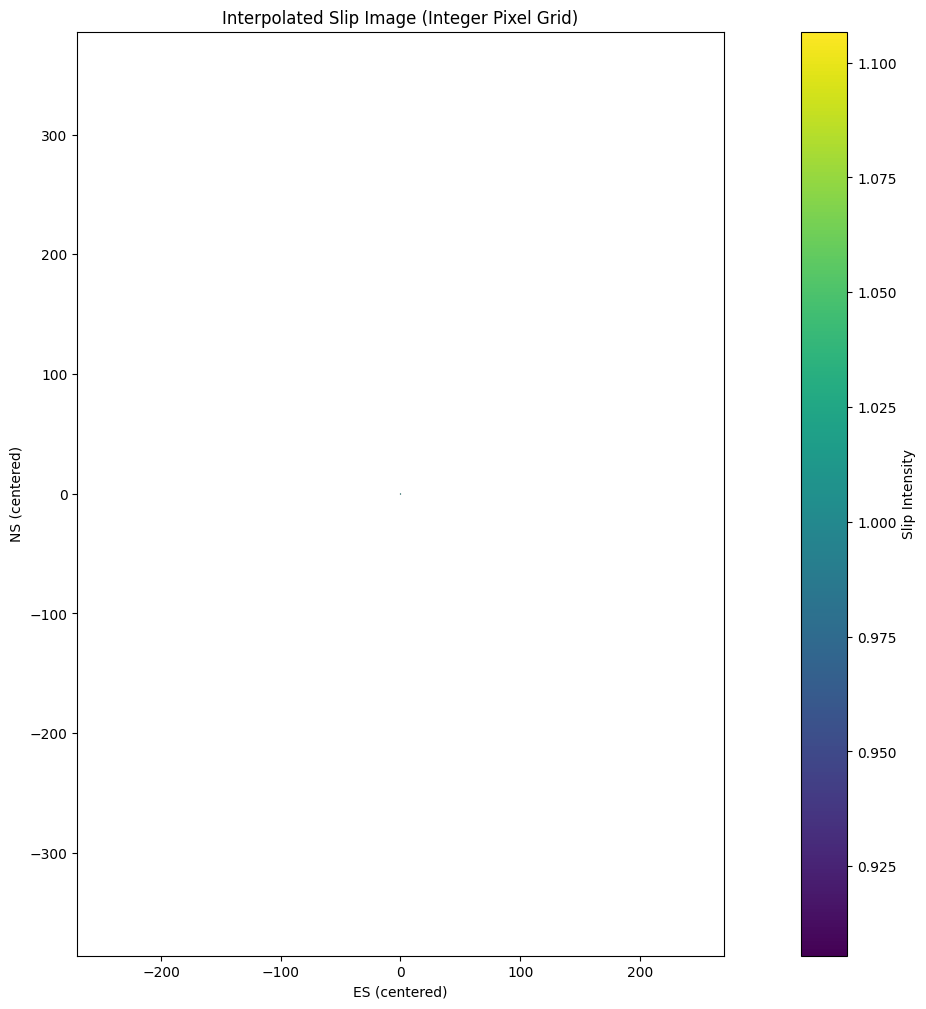

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

df=df_output
s1='s1906SANFRA01SONG.fsp'

dx = df_input[df_input['filename']==s1]['Dx'].values[0]
dy = df_input[df_input['filename']==s1]['Dx'].values[0]
dz = df_input[df_input['filename']==s1]['Dz'].values[0]

# Step 1: Load data from CSV
# Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
es = df[df['filename']==s1]['X==EW'].values*dx/5
ns = df[df['filename']==s1]['Y==NS'].values*dy/5
slip = df[df['filename']==s1]['SLIP'].values/df[df['filename']==s1]['SLIP'].max()

# Step 2: Recenter coordinates so that (0,0) is the center.
# We subtract the mean so that the data is centered.
es_centered = es - np.mean(es)
ns_centered = ns - np.mean(ns)

# Step 3: Define a grid of integer-valued pixel positions.
# Compute grid bounds using the floor/ceil to cover the whole data range.
x_min = int(np.floor(np.min(es_centered)))
x_max = int(np.ceil(np.max(es_centered)))
y_min = int(np.floor(np.min(ns_centered)))
y_max = int(np.ceil(np.max(ns_centered)))

# Create a meshgrid with integer positions.
grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                             np.arange(y_min, y_max + 1))

# Step 4: Interpolate slip values onto the integer grid.
# Points is an array of the centered (x,y) coordinates.
points = np.column_stack((es_centered, ns_centered))
grid_slip = griddata(points, slip, (grid_x, grid_y), method='cubic')


# Optionally, you can replace NaNs (outside the convex hull of your data)
# # For example, with zeros or using nearest neighbor interpolation:
# grid_slip = np.where(np.isnan(grid_slip),
#                      griddata(points, slip, (grid_x, grid_y), method='nearest'),
#                      grid_slip)

# Step 5: Visualize the image.
plt.figure(figsize=(20, 12))
plt.imshow(grid_slip, extent=(x_min, x_max, y_min, y_max),
           origin='lower', cmap='viridis')
plt.colorbar(label='Slip Intensity')
plt.title("Interpolated Slip Image (Integer Pixel Grid)")
plt.xlabel("ES (centered)")
plt.ylabel("NS (centered)")
plt.show()

# Optionally, save the image.
plt.imsave("interpolated_slip_image.png", grid_slip, cmap='viridis',
           vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))


In [36]:
slip.shape

(48,)

In [19]:
df_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 64 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   filename     355 non-null    object 
 1   Event        355 non-null    object 
 2   EventTAG     355 non-null    object 
 3   LAT          355 non-null    float64
 4   LON          355 non-null    float64
 5   DEP          355 non-null    float64
 6   LEN_f        355 non-null    float64
 7   WID          355 non-null    float64
 8   Mw           355 non-null    float64
 9   Mo           355 non-null    float64
 10  STRK         355 non-null    float64
 11  DIP          355 non-null    float64
 12  RAKE         355 non-null    float64
 13  Htop         355 non-null    float64
 14  HypX         355 non-null    float64
 15  HypZ         355 non-null    float64
 16  avTr         355 non-null    float64
 17  avVr         355 non-null    float64
 18  Nx           355 non-null    float64
 19  Nz      

In [20]:
df_input[df_input['filename']=='s1906SANFRA01SONG.fsp']['Dx']

0    10.0
Name: Dx, dtype: float64

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def resize_numpy_image(image_array, new_width, new_height):
    """
    Resize a NumPy array (image) using bilinear interpolation.
    """
    resized = cv2.resize(image_array, (new_width, new_height), interpolation=cv2.INTER_LINEAR)
    return resized

# Example: Create a sample NumPy array (grayscale image)
original_image = df_output[df_output['filename']=='s1906SANFRA01SONG.fsp'][['X==EW', 'Y==NS', 'SLIP']].values

initial_len = df_output[df_output['filename']=='s1906SANFRA01SONG.fsp'].__len__()
initial_dx = df_input[df_input['filename']=='s1906SANFRA01SONG.fsp']['Dx'].values[0]
initial_dy = df_input[df_input['filename']=='s1906SANFRA01SONG.fsp']['Dz'].values[0]

# Define new dimensions
new_width, new_height = int(initial_len*initial_dx/5), int(initial_len*initial_dy/5)  # Change as needed

# Resize using the function
resized_image = resize_numpy_image(original_image[:, :2], new_width, new_height)

# # Display original and resized images
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(original_image, cmap='gray')
# plt.title("Original Image")

# plt.subplot(1, 2, 2)
# plt.imshow(resized_image, cmap='gray')
# plt.title("Resized Image")

# plt.show()

print(original_image.shape, resized_image.shape)


(48, 3) (115, 96)


In [27]:
import cv2
import numpy as np

def resize_3d_array(image_array, new_x, new_y):
    """
    Resize a 3D NumPy array along x and y dimensions while interpolating the z-dimension.
    
    Parameters:
        image_array (np.array): Input array of shape (X, Y, Z)
        new_x (int): Desired height
        new_y (int): Desired width
    
    Returns:
        np.array: Resized array of shape (new_x, new_y, Z)
    """
    X, Y, Z = image_array.shape
    resized_slices = [cv2.resize(image_array[:, :, i], (new_y, new_x), interpolation=cv2.INTER_LINEAR) for i in range(Z)]
    resized_array = np.stack(resized_slices, axis=-1)  # Stack along the Z dimension
    
    return resized_array

# Example: Create a 3D NumPy array (e.g., 50x50 with 10 channels)
original_image = np.random.rand(50, 50, 10).astype(np.float32)  # 50x50 image with 10 channels

# Define new shape
new_x, new_y = 100, 100  # Change as needed

# Resize the 3D array
resized_image = resize_3d_array(original_image, new_x, new_y)

# Output shape confirmation
print("Original shape:", original_image.shape)
print("Resized shape:", resized_image.shape)


Original shape: (50, 50, 10)
Resized shape: (100, 100, 10)


In [9]:
a = np.load(r'Dataset\slip_arrays_inference\slip_array_s1944TONANK01ICHI.npy')

np.mean(a), np.max(a), np.std(a.flatten())

(0.6254799, 1.9442174, 0.58273154)

In [60]:
import numpy as np
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
from skimage.transform import resize

def lat_lon_convert(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)



    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])

filename = "s1944TONANK01ICHI.fsp"
grid_slip = np.load(fr"Dataset\slip_arrays_inference\slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert(src[src['filename']==filename], input[input['filename']==filename], grid_slip)

C:\Users\atmad\AppData\Local\Temp\ipykernel_13616\4162651578.py:114: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
def lat_lon_convert_combined(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)

    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # --- NEW: Add ground truth slip interpolation ---
    # Interpolate ground truth slip values onto the same grid points
    ground_truth_slip_values = df_truth['SLIP'].values
    ground_truth_slip_interp = griddata(points_xy, ground_truth_slip_values, points_to_convert, method='cubic')
    
    # Add ground truth slip as a new column
    df_final['Ground_Truth_Slip'] = ground_truth_slip_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])


filename = "s1944TONANK01ICHI.fsp"
grid_slip = np.load(fr"Dataset\slip_arrays_inference\slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert_combined(src[src['filename']==filename], input[input['filename']==filename], grid_slip)


C:\Users\atmad\AppData\Local\Temp\ipykernel_13616\82968370.py:107: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [67]:
df_final_

,X_EW,Y_NS,Interpolated_Slip,LAT,LON,Ground_Truth_Slip
2093,42.73144,-95.851443,0.208614,32.907434,136.422617,1.079009
2094,42.98144,-95.851443,0.204497,32.907434,136.425323,1.076038
2095,43.23144,-95.851443,0.200578,32.907434,136.428029,1.073166
3010,42.73144,-95.601443,0.230963,32.909683,136.422616,1.084721
3011,42.98144,-95.601443,0.226497,32.909683,136.425322,1.081770
...,...,...,...,...,...,...
759015,141.98144,110.398557,0.214096,34.763515,137.497076,1.010374
759016,142.23144,110.398557,0.212810,34.763514,137.499783,1.002445
759931,141.73144,110.648557,0.194510,34.765766,137.494369,1.014836
759932,141.98144,110.648557,0.193601,34.765765,137.497076,1.006791


In [71]:
import plotly.express as px
import plotly.graph_objects as go

# First, remove any rows where LAT or LON are NaN, as these cannot be plotted.
df_plot = df_final_.dropna(subset=['LAT', 'LON'])

# Create a single map showing only the interpolated slip values
fig = go.Figure()

# Add interpolated slip scatter plot
fig.add_trace(
    go.Scattermapbox(
        lat=df_plot['LAT'],
        lon=df_plot['LON'],
        mode='markers',
        marker=dict(
            size=df_plot['Interpolated_Slip'] * 10,  # Scale size for visibility
            color=df_plot['Interpolated_Slip'],
            colorscale='Viridis',
            sizemode='diameter',
            sizemin=2,
            sizemax=20,
            colorbar=dict(title="Interpolated Slip")
        ),
        text=df_plot['Interpolated_Slip'],
        hovertemplate='<b>Interpolated Slip</b>: %{text:.4f}<br>' +
                      '<b>Lat</b>: %{lat:.4f}<br>' +
                      '<b>Lon</b>: %{lon:.4f}<extra></extra>',
        name="Interpolated Slip"
    )
)

# Update mapbox settings
fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        zoom=8,
        center=dict(lat=df_plot['LAT'].mean(), lon=df_plot['LON'].mean())
    ),
    title="Predicted Slip Values",
    margin={"r":0,"t":60,"l":0,"b":0},
    height=600,
    width=800
)

fig.show()


ValueError: Invalid property specified for object of type plotly.graph_objs.scattermapbox.Marker: 'sizemax'

Did you mean "sizemin"?

    Valid properties:
        allowoverlap
            Flag to draw all symbols, even if they overlap.
        angle
            Sets the marker orientation from true North, in degrees
            clockwise. When using the "auto" default, no rotation
            would be applied in perspective views which is
            different from using a zero angle.
        anglesrc
            Sets the source reference on Chart Studio Cloud for
            `angle`.
        autocolorscale
            Determines whether the colorscale is a default palette
            (`autocolorscale: true`) or the palette determined by
            `marker.colorscale`. Has an effect only if in
            `marker.color` is set to a numerical array. In case
            `colorscale` is unspecified or `autocolorscale` is
            true, the default palette will be chosen according to
